<Axes: xlabel='Department', ylabel='count'>

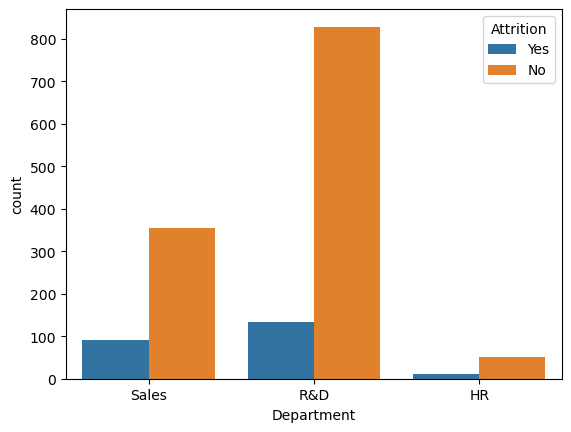

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r'D:\ELEVATE LABS\HR data.csv')
sns.countplot(x='Department', hue='Attrition', data=df)


In [7]:
# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition'].map({'Yes': 1, 'No': 0})  # Convert to numeric

# Convert categorical features
X = pd.get_dummies(X)  # or use LabelEncoder per column

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Train model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))

#Classification
print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))


[[381   0]
 [  0  60]]
CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       381
           1       1.00      1.00      1.00        60

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



<Figure size 640x480 with 0 Axes>

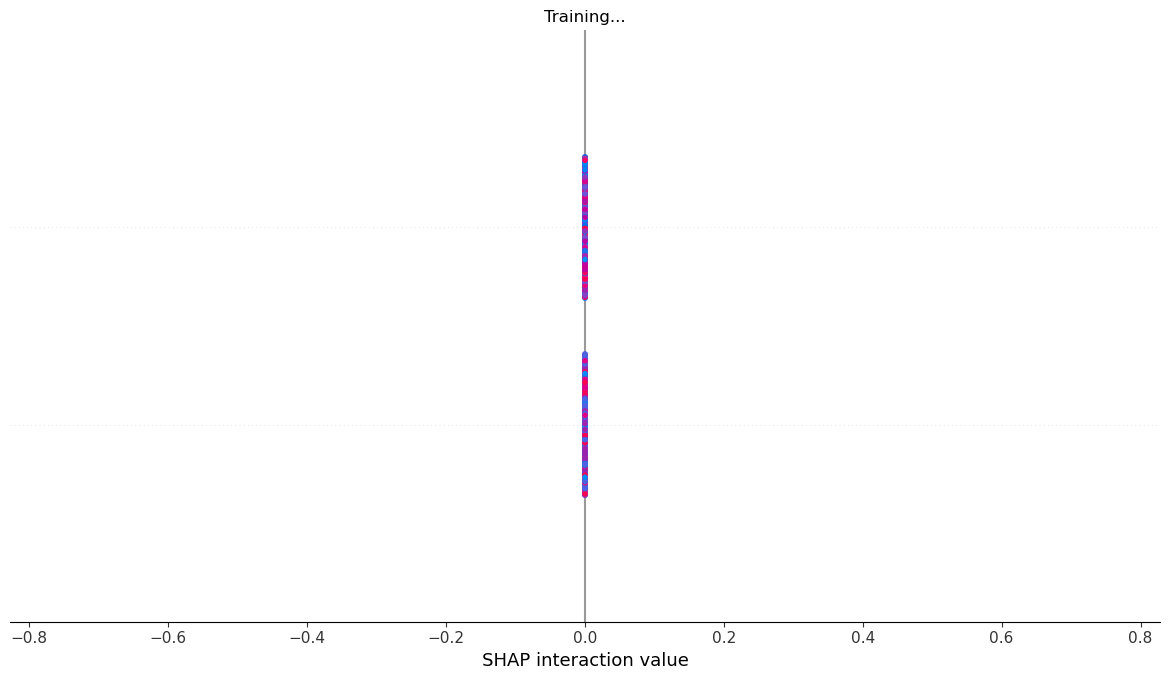

In [11]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)